 - linear regressiom
 - lasso regression
 - ridge regression
 - polynomial regression
 - elastic net regression
 - evaluation metrics - MSE - RMSE - R^2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

## Dataset

**Student Performance (Multiple Linear Regression)** — Kaggle, by `nikhil7280`.
Source: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

The local copy `Student_Performance.csv` was downloaded from a public mirror so the notebook runs without Kaggle credentials.

- 10,000 rows × 6 columns, **no missing values** (already clean).
- Features: `Hours Studied`, `Previous Scores`, `Extracurricular Activities` (Yes/No), `Sleep Hours`, `Sample Question Papers Practiced`.
- Target: `Performance Index` (continuous, 10–100).

In [2]:
df = pd.read_csv("Student_Performance.csv")
print("shape:", df.shape)
print("missing values:", df.isnull().sum().sum())
print("duplicates:", df.duplicated().sum())
df.head()

shape: (10000, 6)
missing values: 0
duplicates: 127


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0000
1,4,82,No,4,2,65.0000
2,8,51,Yes,7,2,45.0000
3,5,52,Yes,5,2,36.0000
4,7,75,No,8,5,66.0000


In [3]:
# Quick EDA
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,4.9929,69.4457,6.5306,4.5833,55.2248
std,2.5893,17.3432,1.6959,2.8673,19.2126
min,1.0000,40.0000,4.0000,0.0000,10.0000
25%,3.0000,54.0000,5.0000,2.0000,40.0000
50%,5.0000,69.0000,7.0000,5.0000,55.0000
75%,7.0000,85.0000,8.0000,7.0000,71.0000
max,9.0000,99.0000,9.0000,9.0000,100.0000


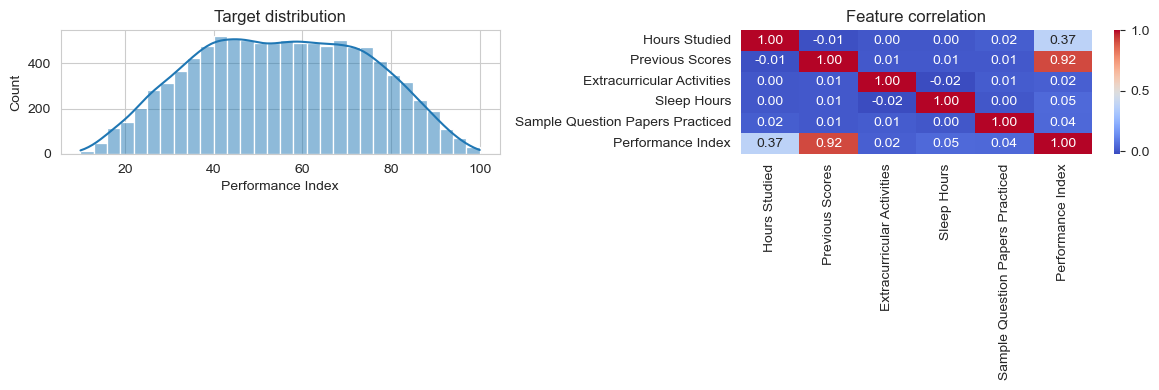

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Performance Index"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Target distribution")

corr_df = df.copy()
corr_df["Extracurricular Activities"] = corr_df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Feature correlation")
plt.tight_layout()
plt.show()

## Preprocess

- Encode the only categorical column (`Extracurricular Activities`) as 0/1.
- Drop the 127 exact-duplicate rows so train/test don't leak.
- Hold out 20% as the test set.
- Standardize features — required for fair regularization in Lasso/Ridge/ElasticNet.

In [5]:
data = df.copy()
data["Extracurricular Activities"] = data["Extracurricular Activities"].map({"Yes": 1, "No": 0})
data = data.drop_duplicates().reset_index(drop=True)

X = data.drop(columns=["Performance Index"])
y = data["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("train:", X_train_s.shape, " test:", X_test_s.shape)

train: (7898, 5)  test: (1975, 5)


In [6]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, y_pred)
    print(f"{name:<22} MSE={mse:7.4f}  RMSE={rmse:6.4f}  R2={r2:.4f}")
    return {"model": name, "MSE": mse, "RMSE": rmse, "R2": r2, "y_pred": y_pred}

results = []

## 1. Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
results.append(evaluate("Linear Regression", lr, X_train_s, X_test_s, y_train, y_test))

print("\nCoefficients:")
for col, coef in zip(X.columns, lr.coef_):
    print(f"  {col:<35} {coef:+.4f}")
print(f"  intercept: {lr.intercept_:.4f}")

Linear Regression      MSE= 4.3059  RMSE=2.0751  R2=0.9884

Coefficients:
  Hours Studied                       +7.3733
  Previous Scores                     +17.6199
  Extracurricular Activities          +0.2869
  Sleep Hours                         +0.8021
  Sample Question Papers Practiced    +0.5401
  intercept: 55.0960


## 2. Lasso Regression (L1)

In [8]:
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_s, y_train)
results.append(evaluate("Lasso (alpha=0.1)", lasso, X_train_s, X_test_s, y_train, y_test))

print("\nCoefficients (zeros mean feature dropped):")
for col, coef in zip(X.columns, lasso.coef_):
    print(f"  {col:<35} {coef:+.4f}")

Lasso (alpha=0.1)      MSE= 4.4102  RMSE=2.1000  R2=0.9881

Coefficients (zeros mean feature dropped):
  Hours Studied                       +7.2746
  Previous Scores                     +17.5201
  Extracurricular Activities          +0.1872
  Sleep Hours                         +0.7005
  Sample Question Papers Practiced    +0.4437


## 3. Ridge Regression (L2)

In [9]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
results.append(evaluate("Ridge (alpha=1.0)", ridge, X_train_s, X_test_s, y_train, y_test))

print("\nCoefficients:")
for col, coef in zip(X.columns, ridge.coef_):
    print(f"  {col:<35} {coef:+.4f}")

Ridge (alpha=1.0)      MSE= 4.3059  RMSE=2.0751  R2=0.9884

Coefficients:
  Hours Studied                       +7.3724
  Previous Scores                     +17.6177
  Extracurricular Activities          +0.2869
  Sleep Hours                         +0.8021
  Sample Question Papers Practiced    +0.5400


## 4. Polynomial Regression (degree 2)
Pipeline: polynomial expansion → standardization → ordinary least squares.

In [10]:
poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])
poly.fit(X_train, y_train)
results.append(evaluate("Polynomial (deg=2)", poly, X_train, X_test, y_train, y_test))

Polynomial (deg=2)     MSE= 4.3052  RMSE=2.0749  R2=0.9884


## 5. Elastic Net Regression (L1 + L2)

In [11]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
enet.fit(X_train_s, y_train)
results.append(evaluate("ElasticNet (a=0.1, l1=0.5)", enet, X_train_s, X_test_s, y_train, y_test))

print("\nCoefficients:")
for col, coef in zip(X.columns, enet.coef_):
    print(f"  {col:<35} {coef:+.4f}")

ElasticNet (a=0.1, l1=0.5) MSE= 5.3264  RMSE=2.3079  R2=0.9857

Coefficients:
  Hours Studied                       +6.9685
  Previous Scores                     +16.7305
  Extracurricular Activities          +0.2329
  Sleep Hours                         +0.7208
  Sample Question Papers Practiced    +0.4715


## Evaluation summary — MSE, RMSE, R²

In [12]:
summary = pd.DataFrame(
    [{"Model": r["model"], "MSE": r["MSE"], "RMSE": r["RMSE"], "R2": r["R2"]} for r in results]
).sort_values("R2", ascending=False).reset_index(drop=True)
summary

,Model,MSE,RMSE,R2
0,Polynomial (deg=2),4.3052,2.0749,0.9884
1,Linear Regression,4.3059,2.0751,0.9884
2,Ridge (alpha=1.0),4.3059,2.0751,0.9884
3,Lasso (alpha=0.1),4.4102,2.1000,0.9881
4,"ElasticNet (a=0.1, l1=0.5)",5.3264,2.3079,0.9857


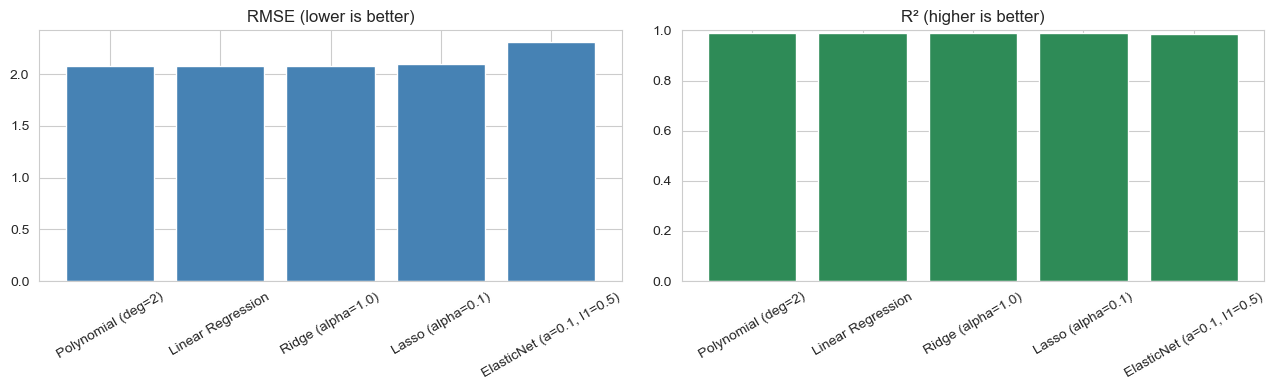

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(summary["Model"], summary["RMSE"], color="steelblue")
axes[0].set_title("RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(summary["Model"], summary["R2"], color="seagreen")
axes[1].set_title("R² (higher is better)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

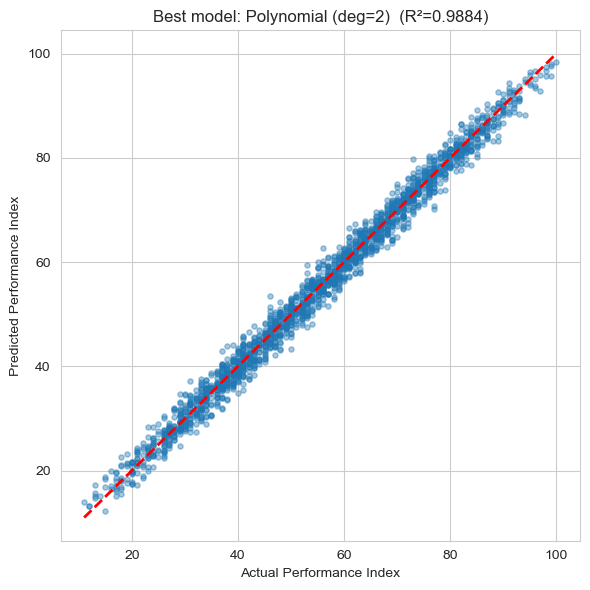

In [14]:
# Predicted vs actual for the best model
best = max(results, key=lambda r: r["R2"])
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best["y_pred"], alpha=0.4, s=14)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title(f"Best model: {best['model']}  (R²={best['R2']:.4f})")
plt.tight_layout()
plt.show()